# RetainAI — Customer Churn Prediction & Retention System\n

---
## 1. Setup & Data Loading

Import required libraries and load the customer dataset.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from scipy.stats import median_abs_deviation
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             roc_auc_score, mean_squared_error, r2_score)

data = pd.read_csv("data/Sales_Marketing_Customer_Dataset.csv")
data.head(20)

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0
5,10006,Male,29.0,Germany,Mumbai,2024-05-08 00:00:00,2023-01-20 00:00:00,Google Ads,Mobile,Monthly,...,2,0,2,SEPA,3.0,10,16.30,467.452413,14,0
6,10007,Male,39.0,UK,New York,2022-01-04 00:00:00,2023-12-05 00:00:00,Email,Mobile,Monthly,...,0,0,3,Card,5.0,10,29.76,1697.386983,1,0
7,10008,Female,NaN,Germany,Berlin,2023-05-11 00:00:00,2024-02-14 00:00:00,Facebook Ads,Desktop,Annual,...,2,0,0,SEPA,3.0,5,18.86,1337.967629,6,0
8,10009,Female,21.0,USA,London,2023-01-14 00:00:00,2024-08-19 00:00:00,Organic,Desktop,Monthly,...,3,0,5,Card,4.0,7,27.14,648.012150,2,1
9,10010,Female,35.0,Germany,Hamburg,2022-12-22 00:00:00,2024-09-04 00:00:00,Email,Tablet,Monthly,...,0,0,3,SEPA,3.0,7,5.22,1360.483364,9,1


---
## 2. Initial Data Exploration

Examine dataset structure, data types, and missing values.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

In [ ]:
data.isnull().sum()

,0
customer_id,0
gender,738
age,1200
country,0
city,0
signup_date,0
last_purchase_date,0
acquisition_channel,0
device_type,0
subscription_type,0


---
## 3. Data Preprocessing

### 3.1 Drop Irrelevant Columns

Remove columns that don't contribute to churn prediction — IDs, dates, redundant or leaky features.

In [ ]:
columns_to_drop = [
    "customer_id", "country", "signup_date", "last_purchase_date",
    "acquisition_channel", "email_open_rate", "email_click_rate",
    "coupon_code", "lifetime_value", "payment_method"
]

data = data.drop(columns=columns_to_drop)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   gender                      14262 non-null  object 
 1   age                         13800 non-null  float64
 2   city                        15000 non-null  object 
 3   device_type                 15000 non-null  object 
 4   subscription_type           15000 non-null  object 
 5   is_premium_user             15000 non-null  int64  
 6   total_visits                15000 non-null  int64  
 7   avg_session_time            15000 non-null  float64
 8   pages_per_session           15000 non-null  float64
 9   total_spent                 13950 non-null  float64
 10  avg_order_value             15000 non-null  float64
 11  discount_used               15000 non-null  int64  
 12  support_tickets             15000 non-null  int64  
 13  refund_requested            150

### 3.2 Handle Missing Values

Impute missing values using appropriate strategies:
- **Categorical:** mode imputation
- **Numerical:** median imputation (robust to outliers)

In [ ]:
data["gender"] = data["gender"].replace("Other", np.nan)
data["gender"] = data["gender"].fillna(data["gender"].mode()[0])
print(f"Gender nulls remaining: {data['gender'].isnull().sum()}")

np.int64(0)

In [ ]:
# Flag unrealistic ages as NaN, then impute with median
data["age"] = data["age"].mask((data["age"] < 18) | (data["age"] > 75))
data["age"] = data["age"].fillna(data["age"].median())
print(f"Age nulls remaining: {data['age'].isnull().sum()}")

In [ ]:
data["satisfaction_score"] = data["satisfaction_score"].fillna(data["satisfaction_score"].median())
print(f"Satisfaction nulls remaining: {data['satisfaction_score'].isnull().sum()}")

In [ ]:
data["total_spent"] = data["total_spent"].fillna(data["total_spent"].median())
print(f"Total spent nulls remaining: {data['total_spent'].isnull().sum()}")

### 3.3 Feature Engineering

Create derived features that capture customer engagement patterns.

In [ ]:
if 'total_spent' in data.columns and 'total_visits' in data.columns:
    data['spend_per_visit'] = data['total_spent'] / (data['total_visits'] + 1e-6)

if 'avg_session_time' in data.columns and 'total_visits' in data.columns:
    data['total_time_spent'] = data['avg_session_time'] * data['total_visits']

### 3.4 Verify Data Quality

Confirm all missing values have been handled and check for duplicate records.

In [ ]:
data.isnull().sum()

,0
gender,0
age,0
city,0
device_type,0
subscription_type,0
is_premium_user,0
total_visits,0
avg_session_time,0
pages_per_session,0
total_spent,0


In [ ]:
data.duplicated().sum()

np.int64(0)

---
## 4. Exploratory Data Analysis

### 4.1 Distribution of Numerical Features

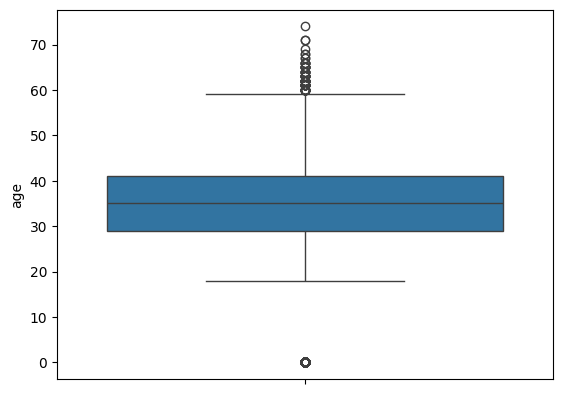

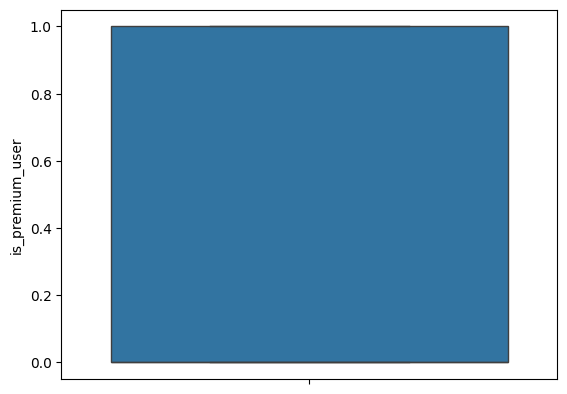

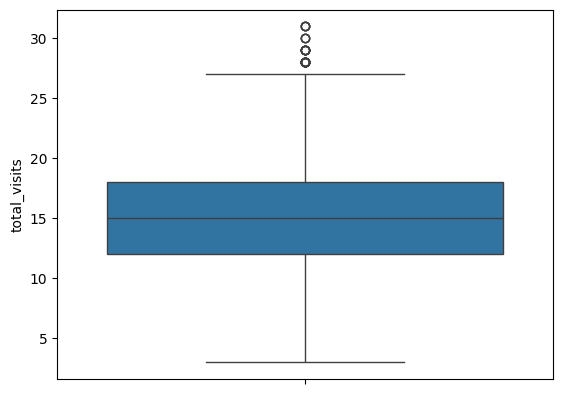

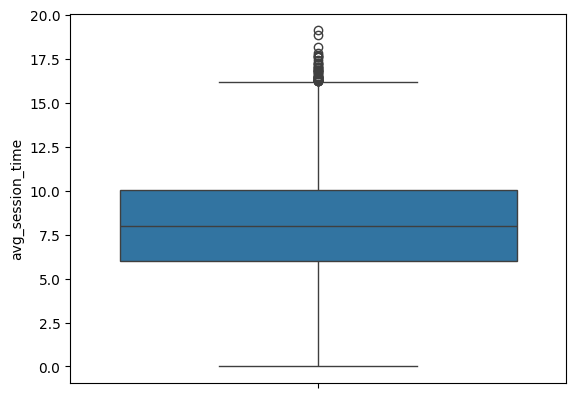

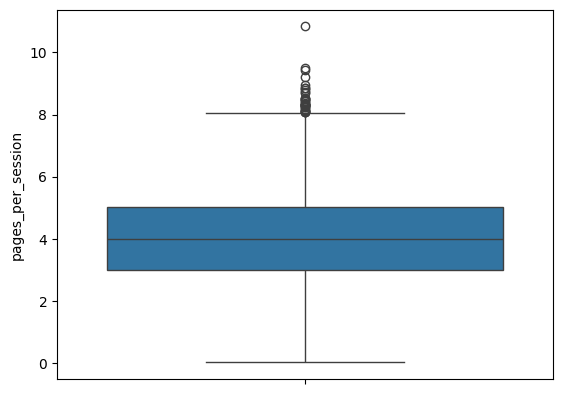

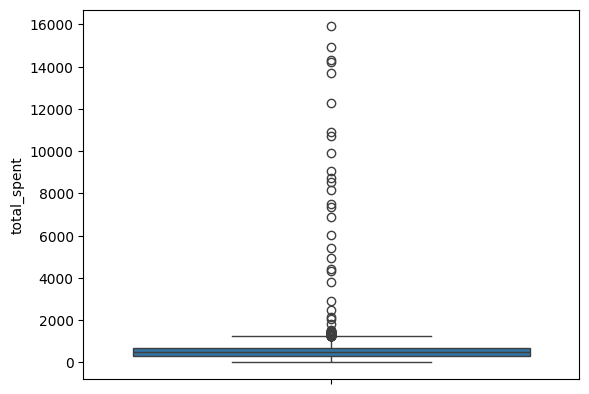

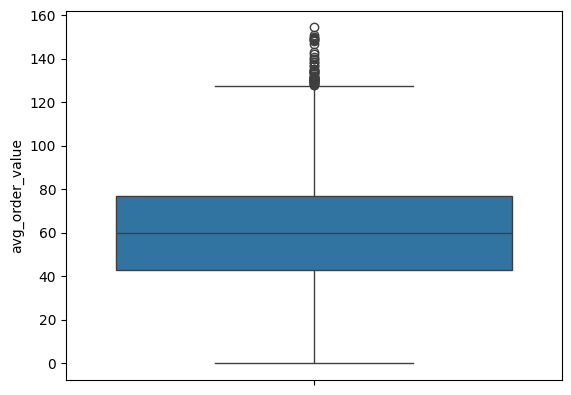

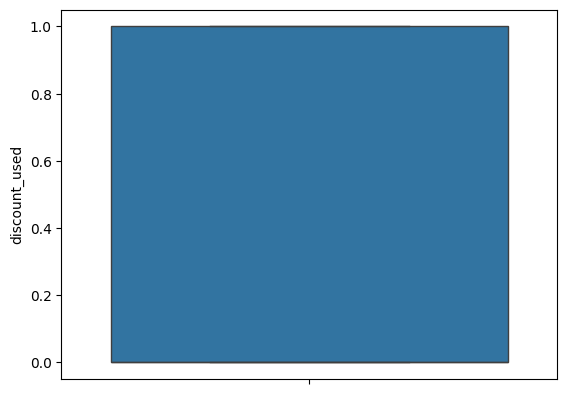

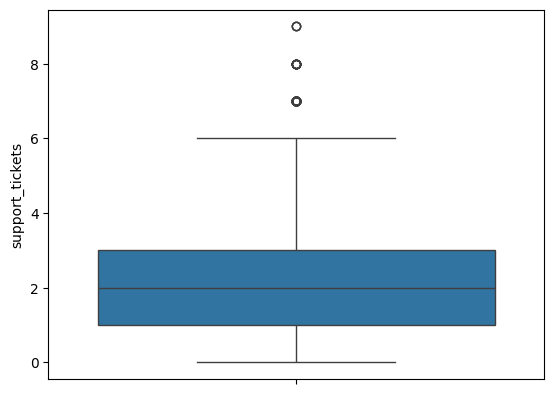

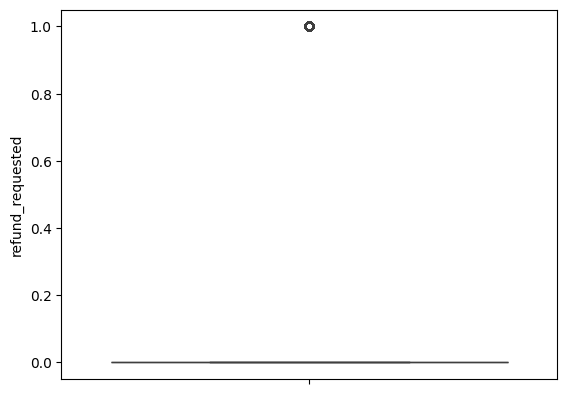

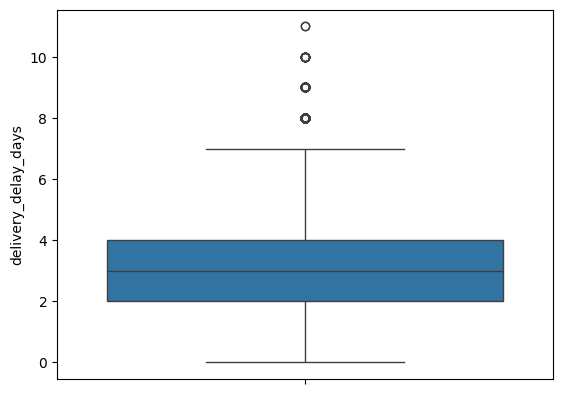

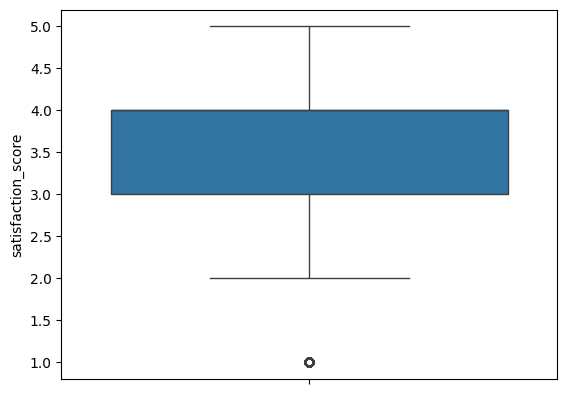

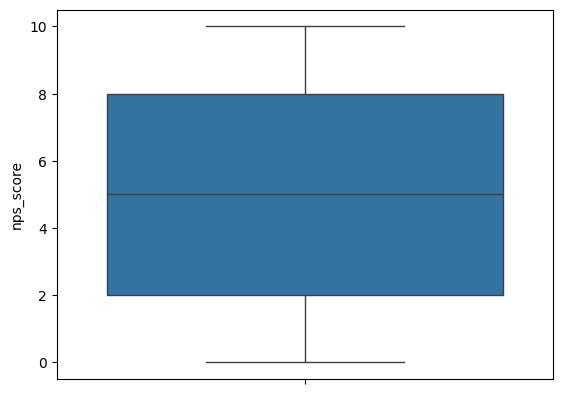

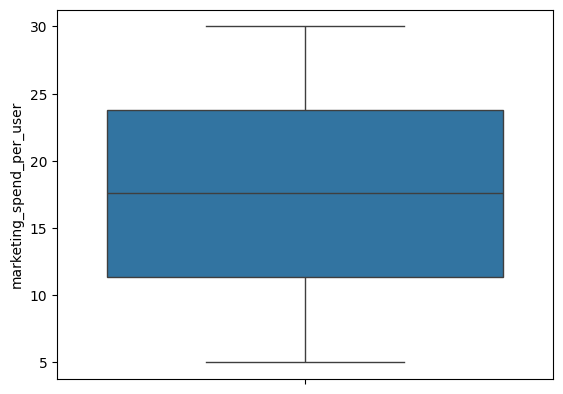

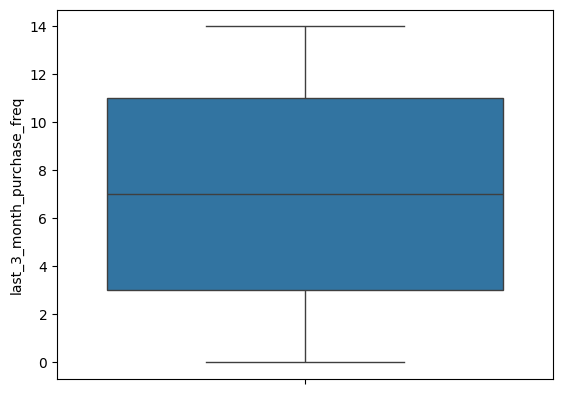

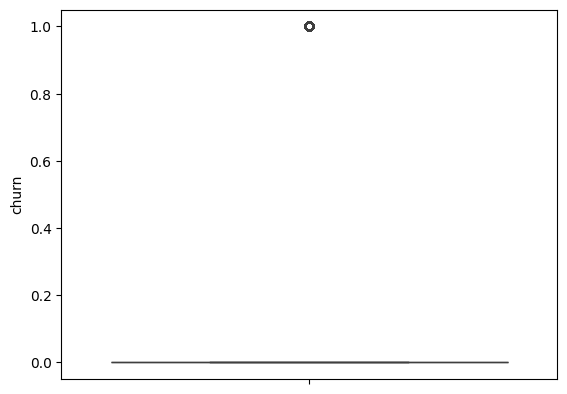

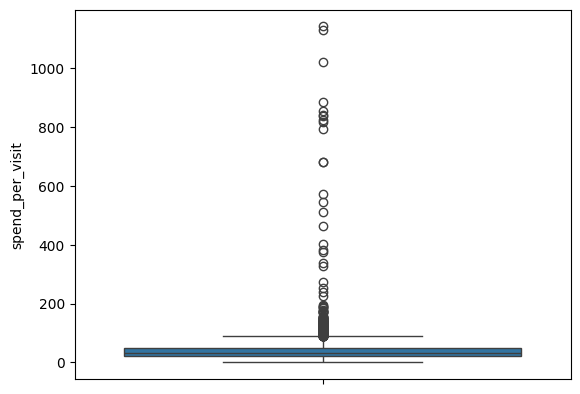

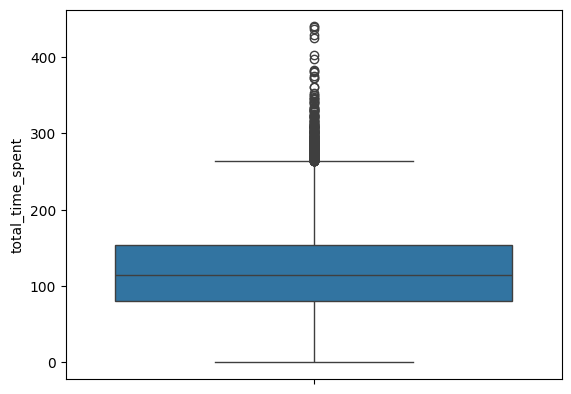

In [ ]:
numeric_columns = data.select_dtypes(include=np.number).columns
for i in numeric_columns :
  sns.boxplot(data[i])
  plt.show()

### 4.2 Target Variable Distribution

Visualise the class balance of the `churn` target variable to assess imbalance.

In [ ]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
churn_counts = data['churn'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(churn_counts.index.astype(str), churn_counts.values, color=colors, edgecolor='white')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].set_title('Churn Class Distribution')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Not Churned (0)', 'Churned (1)'])

# Add count labels on bars
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=['Not Churned', 'Churned'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            explode=(0, 0.05), shadow=True)
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.show()

print(f'\nClass ratio: {churn_counts[0]/churn_counts[1]:.1f} : 1 (majority : minority)')

### 4.3 Correlation Analysis

Examine feature correlations to understand relationships with the target variable.

In [ ]:
# Correlation heatmap
numeric_data = data.select_dtypes(include=np.number)
corr_matrix = numeric_data.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
print('\nTop correlations with churn:')
print(corr_matrix['churn'].drop('churn').sort_values(key=abs, ascending=False).round(3))

---
## 5. Outlier Treatment

Use the IQR method to detect and cap outliers. Values beyond 1.5× IQR are replaced with the column median.

In [ ]:
X = data.drop("churn", axis=1)
y = data["churn"]

In [ ]:
numeric_columns = X.select_dtypes(include=np.number).columns
for col in numeric_columns:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    median_val = X[col].median()

    X.loc[(X[col] < lower_bound) | (X[col] > upper_bound), col] = median_val

### Boxplots After Outlier Treatment

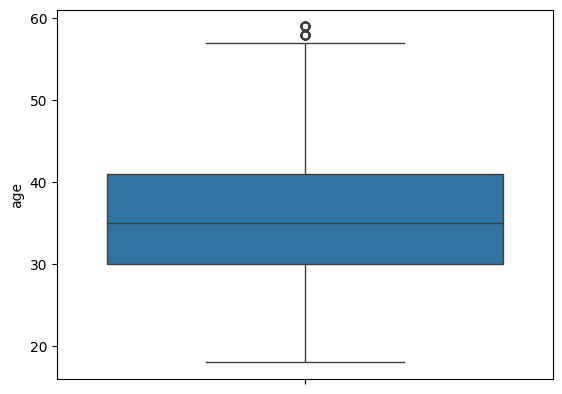

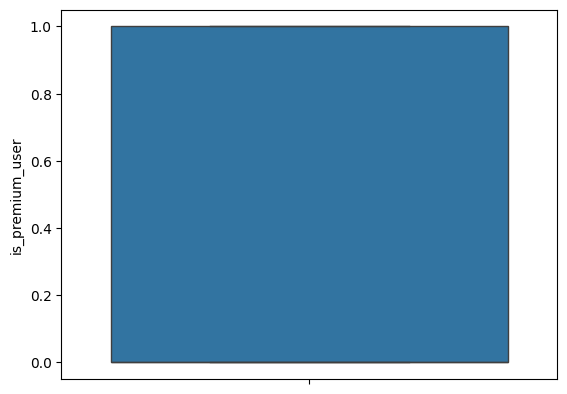

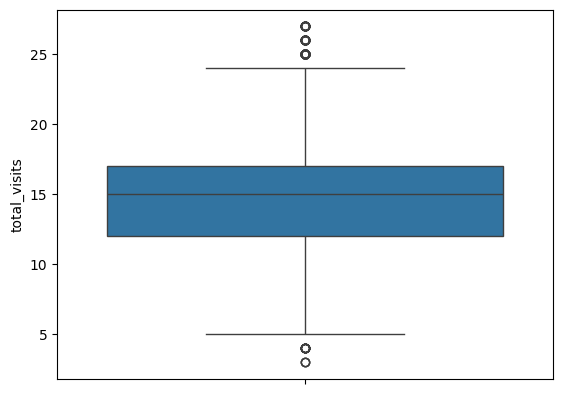

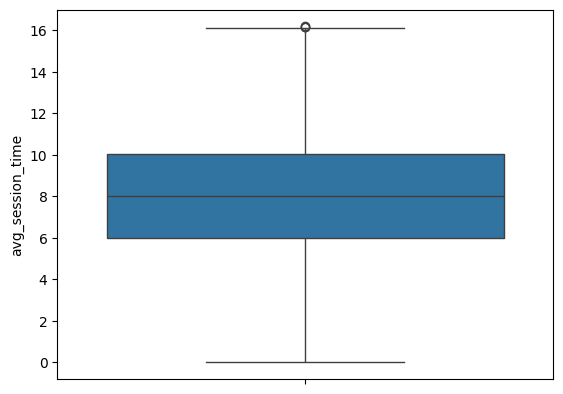

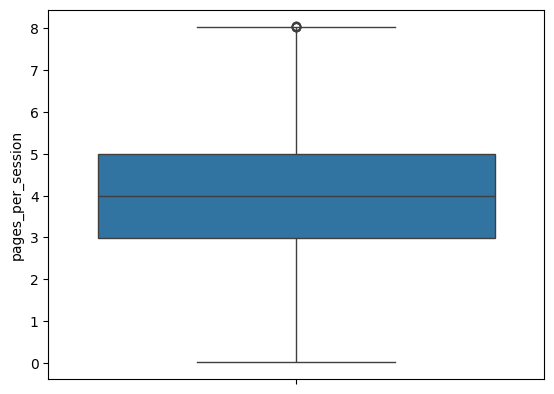

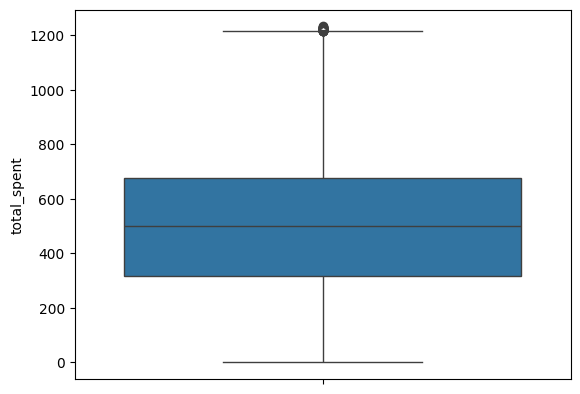

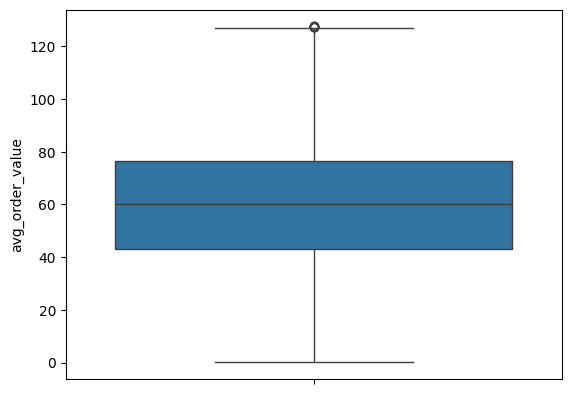

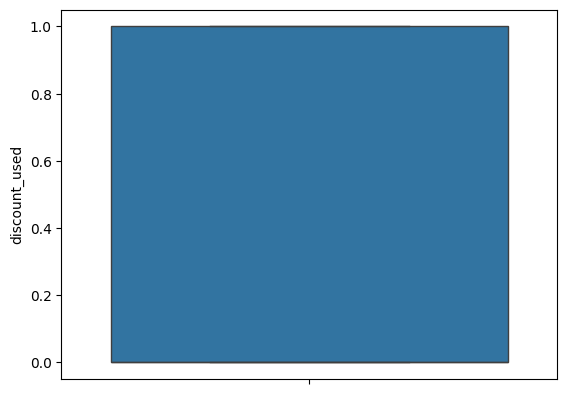

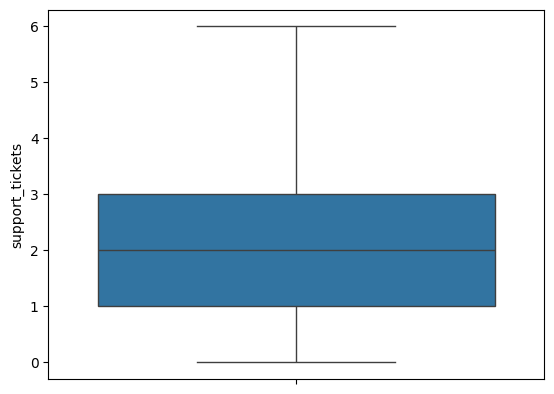

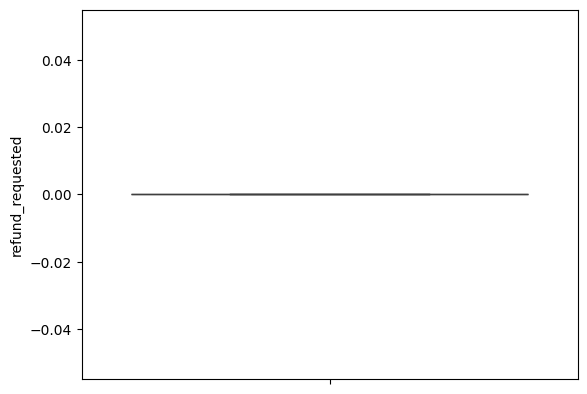

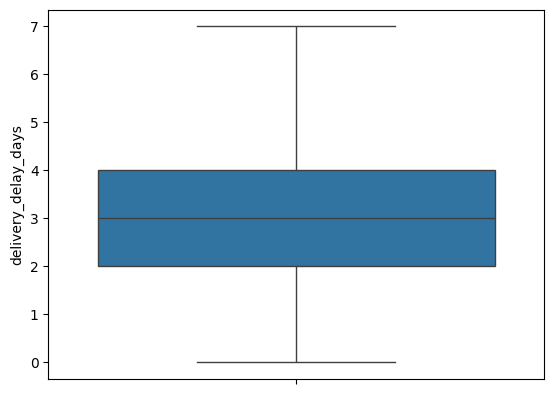

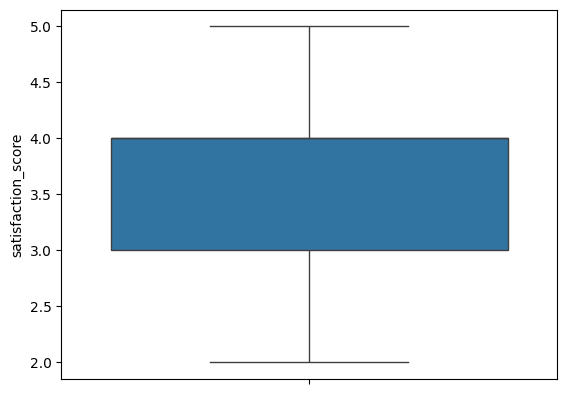

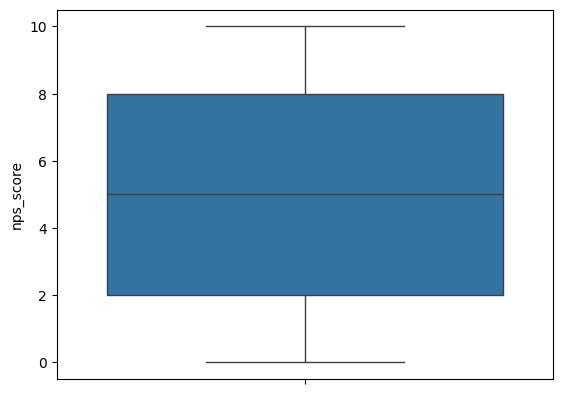

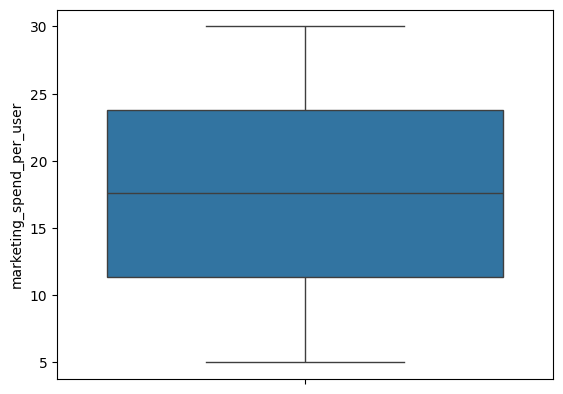

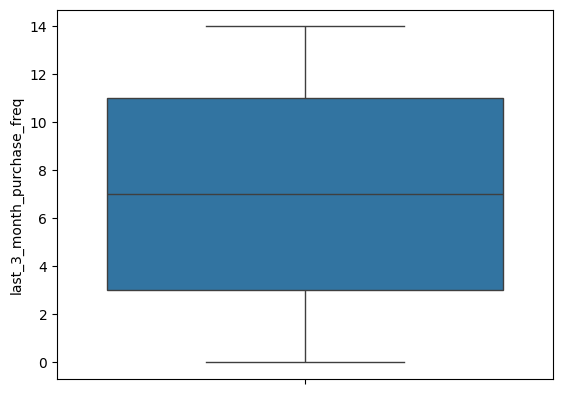

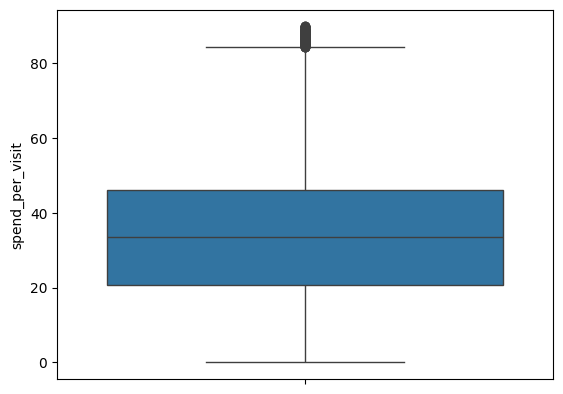

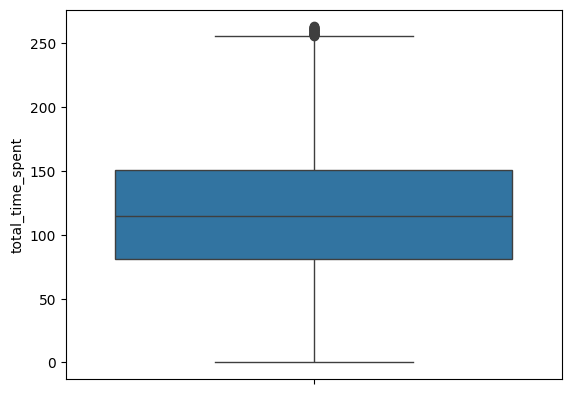

In [ ]:
numeric_columns = X.select_dtypes(include=np.number).columns
for i in numeric_columns :
  sns.boxplot(X[i])
  plt.show()

---
## 6. Feature Encoding & Scaling

- **One-Hot Encoding** for categorical features
- **Standard Scaling** to normalise feature magnitudes for distance-based algorithms

### 6.1 One-Hot Encoding

In [ ]:
stringCol=X.select_dtypes(include="object").columns

encoder = OneHotEncoder(drop=None, sparse_output=False, dtype=int)

encoded_array = encoder.fit_transform(X[stringCol])
feature_names = encoder.get_feature_names_out(stringCol)
encoded_df = pd.DataFrame(encoded_array, columns=feature_names, dtype=int)
data_clean = X.drop(columns=stringCol).reset_index(drop=True)
data_encoded = pd.concat([data_clean, encoded_df], axis=1)

data_encoded.to_csv("encoded_onehot_data.csv", index=False)
data_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         15000 non-null  float64
 1   is_premium_user             15000 non-null  int64  
 2   total_visits                15000 non-null  int64  
 3   avg_session_time            15000 non-null  float64
 4   pages_per_session           15000 non-null  float64
 5   total_spent                 15000 non-null  float64
 6   avg_order_value             15000 non-null  float64
 7   discount_used               15000 non-null  int64  
 8   support_tickets             15000 non-null  int64  
 9   refund_requested            15000 non-null  int64  
 10  delivery_delay_days         15000 non-null  int64  
 11  satisfaction_score          15000 non-null  float64
 12  nps_score                   15000 non-null  int64  
 13  marketing_spend_per_user    150

### 6.2 Standard Scaling

In [ ]:
scaler = StandardScaler()
data_encoded_scaled = scaler.fit_transform(data_encoded)
data_encoded_scaled_df = pd.DataFrame(data_encoded_scaled, columns=data_encoded.columns)
data_encoded_rf = data_encoded.values


---
## 7. Modeling

We compare three classification algorithms, each configured with class-imbalance handling:
1. **Logistic Regression** — `class_weight='balanced'`
2. **Random Forest** — `class_weight='balanced'`
3. **XGBoost** — `scale_pos_weight` calibrated to the imbalance ratio

Models are evaluated on the SMOTE-resampled training set and validated with Stratified K-Fold cross-validation.

In [ ]:
# Additional modelling imports
from sklearn.model_selection import StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

### 7.1 Data Split

In [ ]:
X = data_encoded_scaled
y = data["churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

### 7.2 Handling Class Imbalance with SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

# Applying SMOTE only on training not test
smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_train_resampled))

Before SMOTE: [10162  1838]
After SMOTE: [10162 10162]


Initially, the model was biased toward the majority class, resulting in very low recall for churned customers. To address this, we applied SMOTE to balance the dataset, which significantly will improve the model's ability to detect churn.

### 7.3 XGBoost Automatic Imbalance Handling

In [ ]:
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

### 7.4 Define Models (with Imbalance Handling)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    )
}

### 7.5 Training & Evaluation Function

In [ ]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }
    cm = confusion_matrix(y_test, y_pred)
    return results, cm

### 7.6 Train All Models & Compare

In [ ]:
results = {}
confusion_matrices = {}

for name, model in models.items():
    print(f"Training {name}...")
    res, cm = evaluate_model(model, X_train_resampled, y_train_resampled, X_test, y_test)
    results[name] = res
    confusion_matrices[name] = cm

    print(f"\nConfusion Matrix for {name}:")
    print(cm)
    print("-" * 40)

# Sort results as before
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)
print("\nFinal Model Comparison:")
print(results_df.round(3))

Training Logistic Regression...

Confusion Matrix for Logistic Regression:
[[1794  746]
 [ 132  328]]
----------------------------------------
Training Random Forest...

Confusion Matrix for Random Forest:
[[2198  342]
 [  92  368]]
----------------------------------------
Training XGBoost...

Confusion Matrix for XGBoost:
[[2188  352]
 [  77  383]]
----------------------------------------

Final Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
XGBoost                 0.857      0.521   0.833     0.641    0.886
Random Forest           0.855      0.518   0.800     0.629    0.872
Logistic Regression     0.707      0.305   0.713     0.428    0.766


### 7.7 Confusion Matrices

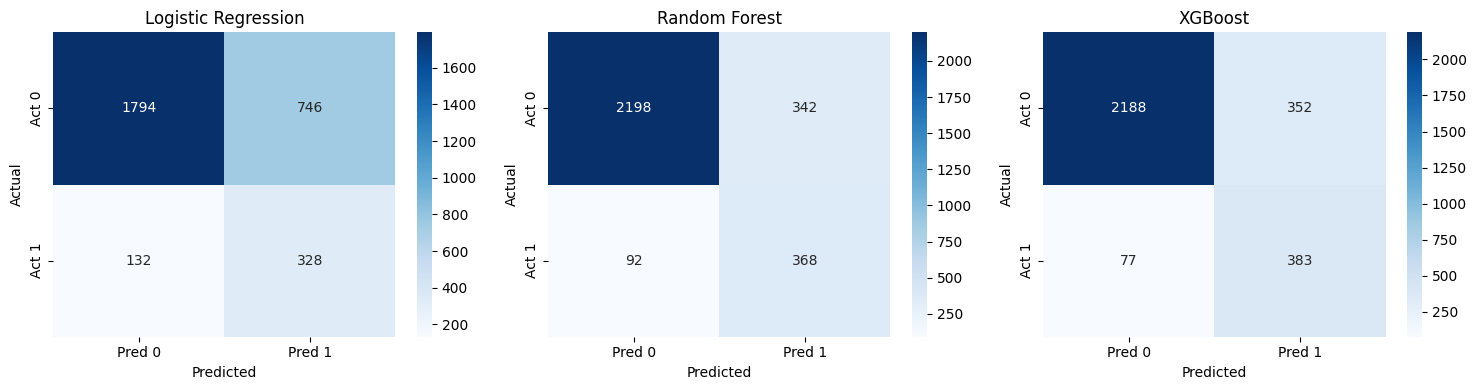

In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(5 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for ax, (name, cm) in zip(axes, confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred 0', 'Pred 1'],
                yticklabels=['Act 0', 'Act 1'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 7.8 Cross-Validation

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    cv_results[name] = scores.mean()

cv_results_df = pd.DataFrame.from_dict(cv_results, orient='index', columns=["CV ROC-AUC"])
print("\nCross Validation Results:")
print(cv_results_df)


Cross Validation Results:
                     CV ROC-AUC
Logistic Regression    0.770330
Random Forest          0.877152
XGBoost                0.878815


### 7.9 Best Model Selection

In [ ]:
# Merge results into a single table
comparison_summary = pd.DataFrame({
    'Test ROC-AUC': results_df['ROC-AUC'],
    'CV ROC-AUC': cv_results_df['CV ROC-AUC']
})

# Calculate the average between the two results (to measure overall performance)
comparison_summary['Combined_Score'] = (comparison_summary['Test ROC-AUC'] + comparison_summary['CV ROC-AUC']) / 2

# Calculate the Gap to check for stability
# A smaller Gap indicates a more stable model (less overfitting)
comparison_summary['Gap'] = abs(comparison_summary['Test ROC-AUC'] - comparison_summary['CV ROC-AUC'])

# Sort models based on the Combined Score
comparison_summary = comparison_summary.sort_values(by='Combined_Score', ascending=False)

print("Combined Model Comparison (Test & CV):")
print(comparison_summary.round(4))

# Select the best model
best_model_name = comparison_summary.index[0]
best_model = models[best_model_name]

print(f"\nFinal Chosen Model: {best_model_name}")
print(f"Reason: Highest combined score of {comparison_summary.loc[best_model_name, 'Combined_Score']:.4f} "
      f"with a gap of {comparison_summary.loc[best_model_name, 'Gap']:.4f}")

Combined Model Comparison (Test & CV):
                     Test ROC-AUC  CV ROC-AUC  Combined_Score     Gap
XGBoost                    0.8865      0.8788          0.8827  0.0077
Random Forest              0.8724      0.8772          0.8748  0.0048
Logistic Regression        0.7664      0.7703          0.7684  0.0039

Final Chosen Model: XGBoost
Reason: Highest combined score of 0.8827 with a gap of 0.0077


### 7.10 Hyperparameter Tuning (GridSearchCV)

In [ ]:
from sklearn.model_selection import GridSearchCV
import xgboost as xgb

# Define the Hyperparameters Grid (reduced for faster execution)
param_grid = {
    'n_estimators': [150, 300],           # Reduced number of boosting rounds
    'max_depth': [4, 6],                  # Reduced tree depth options
    'learning_rate': [0.05, 0.1],         # Reduced learning rate options
    'subsample': [0.8, 1.0],              # Reduced subsample options
    'colsample_bytree': [0.8, 1.0],     # Reduced column subsample options
    'scale_pos_weight': [5, 10]         # Reduced options for handling class imbalance
}

# Setup GridSearch
# We use scoring='roc_auc' as it is our primary evaluation metric
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=param_grid,
    cv=cv,             # Using the same Cross-validation strategy defined earlier
    scoring='roc_auc',
    n_jobs=-1,         # Utilize all processor cores to speed up the search
    verbose=1          # Shows progress logs during execution
)

# Start training on the balanced (Resampled) data
print("Starting Grid Search... this may take a few minutes.")
grid_search.fit(X_train_resampled, y_train_resampled)

# Display the best results
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Evaluate the final optimized model on the Test Set
best_xgb_model = grid_search.best_estimator_
final_test_results = evaluate_model(best_xgb_model, X_train_resampled, y_train_resampled, X_test, y_test)

print("\nFinal Optimized XGBoost Results on Test Set:")
print(final_test_results)

Starting Grid Search... this may take a few minutes.
Fitting 5 folds for each of 64 candidates, totalling 320 fits

Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'scale_pos_weight': 5, 'subsample': 0.8}
Best CV ROC-AUC: 0.9796

Final Optimized XGBoost Results on Test Set:
({'Accuracy': 0.858, 'Precision': 0.5234806629834254, 'Recall': 0.8239130434782609, 'F1 Score': 0.6402027027027027, 'ROC-AUC': np.float64(0.8879014036288942)}, array([[2195,  345],
       [  81,  379]]))


### 7.11 Analysis & Key Insights

1- Initial Assessment & Problem Identification
- The Baseline: Started with an initial model using standard parameters.

- The Discovery: Observed high overall Accuracy (~85%) but extremely poor performance on the minority class (Recall ~0.11).

- The Diagnosis: Identified a severe Class Imbalance issue (approx. 85% vs. 15% distribution). Realized that the model was "biased" toward the majority class, making the high accuracy misleading.

2- Handling Data Imbalance (The Turning Point)
- The Strategy: Applied resampling techniques to balance the training set. This was crucial to force the model to learn the patterns of the minority class.

- The Outcome: Successfully shifted the model focus. The Recall for the minority class jumped significantly (from 0.11 to over 0.80), proving the model could finally "see" the rare cases.

3- Model Comparison & Selection (The Selection Framework)
- The Experiment: Compared three different architectures: Logistic Regression, Random Forest, and XGBoost.

- The Methodology: Used a dual-evaluation approach:

  1. Test Set Performance: To see how the model handles unseen data.

  2. Cross-Validation (CV): To ensure the results were stable across different data folds.

- The Innovation: Developed a Combined Score & Stability Gap metric. Instead of just picking the highest number, we chose the model that provided the best balance between high performance and the smallest gap between Test and CV results.

- The Winner: XGBoost was selected as the final model due to its superior ROC-AUC and stability.

4- Hyperparameter Tuning & Deep Analysis
- The Experiment: Performed a GridSearchCV on XGBoost to find the optimal settings (learning rate, depth, scale_pos_weight).

- The Critical Insight: Found that while the GridSearch "technically" found a solution with high CV scores, it slightly decreased the Recall on the actual Test set compared to our initial balanced model.

- The Decision: We prioritized Generalization over "perfect" training scores. We chose the model that maintained the highest Recall (0.82), as catching the minority class was the primary goal of the project.
------------------------------------
- Why didn't you trust the 85% Accuracy?

  Accuracy is a deceptive metric in imbalanced datasets. If 85% of my data is Class 0, a model can get 85% accuracy by just guessing '0' every time. I looked at the F1-Score and Recall to find the true performance.

- How did you choose the best model?

  I didn't just pick the highest test score. I compared the Test ROC-AUC with the Cross-Validation ROC-AUC. I looked for the 'Stability Gap'—the smaller the gap, the more I can trust that the model will work in the real world.

- Why did you use SMOTE/Resampling?

  To balance the class weights. Without it, the model's loss function doesn't penalize mistakes on the minority class enough. Resampling ensures the model learns the features of both classes equally.

- What was the most challenging part?

  Balancing the trade-off between Precision and Recall. We achieved a high Recall of 0.82, which is excellent for catching target cases, even if it meant a slight trade-off in Precision.

---

## 8. Recommendation System

In this section we build a **content-based customer recommendation system**.
Using the same customer feature space already prepared for churn modelling,
we compute pairwise cosine similarity to identify the customers most similar
to any given customer. We then combine those similarity scores with the
churn-risk probability produced by our best XGBoost model to generate
**personalised retention recommendations** for high-risk customers.

**Pipeline overview**

1. Compute cosine-similarity matrix from scaled features.
2. Build `get_similar_customers()` — returns top-N most similar customers.
3. Derive churn-risk probability from the trained XGBoost model.
4. Cluster customers with K-Means to label behavioural segments.
5. Map each segment to a human-readable retention strategy.
6. Present a full recommendation report for any customer.

## 1. Imports

In [ ]:
# Recommendation System – imports
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
print('Imports loaded successfully.')

Imports loaded successfully.


## 2. Cosine-Similarity Matrix

We use the already-scaled feature matrix `data_encoded_scaled` so every
feature contributes equally regardless of its original scale.

In [ ]:
# Build cosine-similarity matrix (rows = customers)
similarity_matrix = cosine_similarity(data_encoded_scaled)

print(f'Similarity matrix shape: {similarity_matrix.shape}')
print(f'Sample similarity scores for customer 0:')
print(similarity_matrix[0][:10].round(4))

Similarity matrix shape: (15000, 15000)
Sample similarity scores for customer 0:
[ 1.     -0.3034 -0.0419  0.2443 -0.1111  0.1268 -0.0536  0.2467 -0.129
 -0.1343]


## 3. Similar-Customer Lookup

Given a customer index, `get_similar_customers()` returns the top-N
most similar customers (excluding the customer themselves).

In [ ]:
def get_similar_customers(customer_idx, top_n=5):
    """
    Return the top-N most similar customers to `customer_idx`.

    Parameters
    ----------
    customer_idx : int  – row index of the target customer.
    top_n        : int  – number of similar customers to return.

    Returns
    -------
    pd.DataFrame with columns [customer_index, similarity_score].
    """
    scores = similarity_matrix[customer_idx]          # similarity to every other customer
    similar_indices = scores.argsort()[::-1]          # sort descending
    similar_indices = similar_indices[similar_indices != customer_idx]  # exclude self
    top_indices = similar_indices[:top_n]

    return pd.DataFrame({
        'customer_index': top_indices,
        'similarity_score': scores[top_indices].round(4)
    }).reset_index(drop=True)


# Quick test
similar = get_similar_customers(0, top_n=5)
print('Top 5 customers most similar to customer 0:')
print(similar)

Top 5 customers most similar to customer 0:
   customer_index  similarity_score
0           13646            0.6589
1            6738            0.6585
2            1126            0.6558
3            4439            0.6506
4            3931            0.6493


## 4. Churn-Risk Probability

We reuse the tuned XGBoost model (`best_xgb_model`) to assign every
customer a churn-risk probability.  
Customers with probability **≥ 0.5** are flagged as high-risk.

In [ ]:
# Predict churn probability for ALL customers
churn_prob = best_xgb_model.predict_proba(data_encoded_scaled)[:, 1]

# Attach to a results dataframe
customer_profiles = data_encoded.copy()
customer_profiles['churn_probability'] = churn_prob
customer_profiles['high_risk'] = (churn_prob >= 0.5).astype(int)

print(f'Total customers : {len(customer_profiles)}')
print(f'High-risk (>=50%): {customer_profiles["high_risk"].sum()}')
print(customer_profiles[['churn_probability', 'high_risk']].describe().round(3))

Total customers : 15000
High-risk (>=50%): 3509
       churn_probability  high_risk
count          15000.000  15000.000
mean               0.271      0.234
std                0.310      0.423
min                0.001      0.000
25%                0.032      0.000
50%                0.125      0.000
75%                0.438      0.000
max                0.967      1.000


## 5. Customer Segmentation with K-Means

K-Means clustering groups customers into **behavioural segments**.
Each segment is then mapped to a tailored retention strategy.

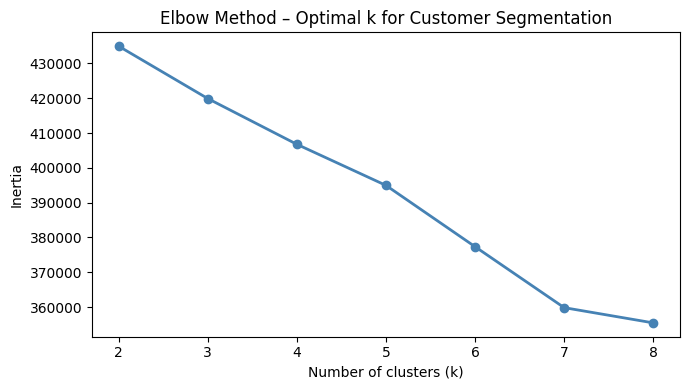

In [ ]:
# --- Elbow method to pick k ---
inertias = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(data_encoded_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method – Optimal k for Customer Segmentation')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [ ]:
# --- Fit final K-Means with k=4 ---
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
customer_profiles['segment'] = kmeans.fit_predict(data_encoded_scaled)

print('Customers per segment:')
print(customer_profiles['segment'].value_counts().sort_index())

Customers per segment:
segment
0    3895
1    3771
2    3647
3    3687
Name: count, dtype: int64


## 6. Segment Profiles

Inspect the mean churn probability and key behavioural features per segment
to understand *what* each cluster represents.

In [ ]:
# Select a few interpretable columns that exist in the original `data` df
profile_cols = ['churn_probability']

# Add original numeric columns back if available
for col in ['total_spent', 'total_visits', 'satisfaction_score',
            'spend_per_visit', 'avg_session_time']:
    if col in data.columns:
        profile_cols.append(col)

# Temporarily attach segment to `data`
data_seg = data.copy()
data_seg['segment'] = customer_profiles['segment'].values
data_seg['churn_probability'] = customer_profiles['churn_probability'].values

segment_profiles = data_seg.groupby('segment')[profile_cols].mean().round(3)
print('Mean feature values per segment:')
print(segment_profiles)

Mean feature values per segment:
         churn_probability  total_spent  total_visits  satisfaction_score  \
segment                                                                     
0                    0.271      524.179        14.985               3.586   
1                    0.276      511.995        15.067               3.618   
2                    0.279      533.381        14.895               3.587   
3                    0.256      520.998        15.055               3.642   

         spend_per_visit  avg_session_time  
segment                                     
0                 37.706             8.064  
1                 36.776             7.986  
2                 38.565             8.011  
3                 37.123             8.021  


## 7. Retention Strategy Mapping

Based on segment churn probability and behavioural profile, we assign each
segment a descriptive label and a concrete retention recommendation.

In [ ]:
# Sort segments by churn probability to label them consistently
seg_order = segment_profiles['churn_probability'].sort_values(ascending=False).index.tolist()

# Human-readable labels (highest churn risk → lowest)
SEGMENT_LABELS = {
    seg_order[0]: 'Critical Risk',
    seg_order[1]: 'High Risk',
    seg_order[2]: 'Moderate Risk',
    seg_order[3]: 'Low Risk',
}

RETENTION_STRATEGIES = {
    'Critical Risk': (
        'Immediate personal outreach by a senior account manager. '
        'Offer a premium loyalty reward, exclusive discount (20-30%), '
        'and a dedicated support line. Schedule a satisfaction survey call '
        'within 48 hours.'
    ),
    'High Risk': (
        'Trigger an automated win-back email series with a time-limited '
        'coupon (10-15%). Invite to a loyalty programme and highlight new '
        'features/products that match their past purchase history.'
    ),
    'Moderate Risk': (
        'Enrol in a re-engagement campaign: monthly newsletter with '
        'personalised product recommendations, and a small birthday '
        'or anniversary gift voucher.'
    ),
    'Low Risk': (
        'Maintain engagement via regular product updates and a referral '
        'programme incentive. Reward loyalty with early access to new '
        'products or features.'
    ),
}

customer_profiles['segment_label'] = customer_profiles['segment'].map(SEGMENT_LABELS)

print('Segment label distribution:')
print(customer_profiles['segment_label'].value_counts())

Segment label distribution:
segment_label
Moderate Risk    3895
High Risk        3771
Low Risk         3687
Critical Risk    3647
Name: count, dtype: int64


## 8. Segment Visualisation

Distribution of churn probability across segments.

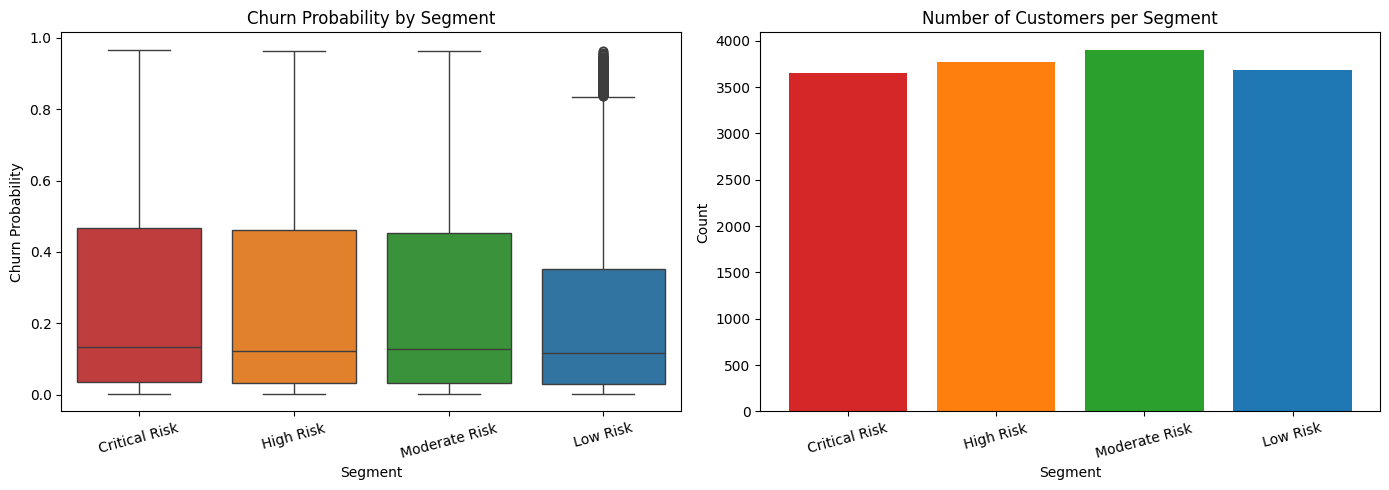

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: churn probability distribution per segment ---
order = ['Critical Risk', 'High Risk', 'Moderate Risk', 'Low Risk']
palette = {'Critical Risk': '#d62728', 'High Risk': '#ff7f0e',
           'Moderate Risk': '#2ca02c', 'Low Risk': '#1f77b4'}

sns.boxplot(
    data=customer_profiles,
    x='segment_label', y='churn_probability',
    order=order, palette=palette, ax=axes[0]
)
axes[0].set_title('Churn Probability by Segment')
axes[0].set_xlabel('Segment')
axes[0].set_ylabel('Churn Probability')
axes[0].tick_params(axis='x', rotation=15)

# --- Right: customer count per segment ---
counts = customer_profiles['segment_label'].value_counts().reindex(order)
axes[1].bar(counts.index, counts.values,
            color=[palette[s] for s in counts.index])
axes[1].set_title('Number of Customers per Segment')
axes[1].set_xlabel('Segment')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 9. Full Recommendation Engine

`recommend_for_customer()` brings everything together:
- churn-risk probability
- segment label & retention strategy
- top similar customers to benchmark against

In [ ]:
def recommend_for_customer(customer_idx, top_n_similar=5):
    """
    Generate a full retention recommendation report for one customer.

    Parameters
    ----------
    customer_idx   : int – row index of the target customer.
    top_n_similar  : int – how many similar customers to show.

    Returns
    -------
    dict with keys: churn_probability, segment, strategy, similar_customers.
    """
    row = customer_profiles.iloc[customer_idx]

    churn_prob  = row['churn_probability']
    segment_lbl = row['segment_label']
    strategy    = RETENTION_STRATEGIES[segment_lbl]
    similar     = get_similar_customers(customer_idx, top_n=top_n_similar)

    print('=' * 60)
    print(f'  RETENTION RECOMMENDATION — Customer #{customer_idx}')
    print('=' * 60)
    print(f'  Churn Probability : {churn_prob:.1%}')
    print(f'  Risk Segment      : {segment_lbl}')
    print()
    print('  RECOMMENDED STRATEGY:')
    print(f'  {strategy}')
    print()
    print(f'  TOP {top_n_similar} SIMILAR CUSTOMERS (for benchmarking):')
    print(similar.to_string(index=False))
    print('=' * 60)

    return {
        'churn_probability': churn_prob,
        'segment': segment_lbl,
        'strategy': strategy,
        'similar_customers': similar
    }


# Example: run for customer index 0
report = recommend_for_customer(0, top_n_similar=5)

  RETENTION RECOMMENDATION — Customer #0
  Churn Probability : 0.6%
  Risk Segment      : Low Risk

  RECOMMENDED STRATEGY:
  Maintain engagement via regular product updates and a referral programme incentive. Reward loyalty with early access to new products or features.

  TOP 5 SIMILAR CUSTOMERS (for benchmarking):
 customer_index  similarity_score
          13646            0.6589
           6738            0.6585
           1126            0.6558
           4439            0.6506
           3931            0.6493


## 10. Batch Report – All High-Risk Customers

Generate a summary table of every customer flagged as high-risk
(`churn_probability ≥ 0.50`) with their assigned strategy.

In [ ]:
high_risk_df = customer_profiles[customer_profiles['high_risk'] == 1][
    ['churn_probability', 'segment_label']
].copy()

high_risk_df['strategy'] = high_risk_df['segment_label'].map(RETENTION_STRATEGIES)
high_risk_df = high_risk_df.sort_values('churn_probability', ascending=False).reset_index()
high_risk_df.rename(columns={'index': 'customer_index'}, inplace=True)

print(f'High-risk customers: {len(high_risk_df)}')
print()
# Show first 10 rows with truncated strategy text for readability
display_df = high_risk_df[['customer_index', 'churn_probability', 'segment_label']].head(10)
display_df['churn_probability'] = display_df['churn_probability'].map('{:.1%}'.format)
print(display_df.to_string(index=False))

High-risk customers: 3509

 customer_index churn_probability segment_label
            972             96.7% Critical Risk
          11357             96.4%     High Risk
          14681             96.3% Moderate Risk
           4546             96.3%      Low Risk
           7121             96.3% Moderate Risk
           4853             96.2%      Low Risk
          12382             96.2% Critical Risk
           4121             96.2% Critical Risk
           9098             96.1%     High Risk
           3036             95.9%      Low Risk


## 11. Summary

| Step | Technique | Purpose |
| --- | --- | --- |
| Similarity matrix | Cosine similarity | Find customers with similar behaviour |
| Risk scoring | XGBoost predict_proba | Prioritise who needs intervention most |
| Segmentation | K-Means (k=4) | Group customers into actionable clusters |
| Strategy mapping | Rule-based on segment | Personalise the retention offer |

**Key takeaways**

- Customers in the **Critical Risk** segment require immediate human-led outreach.
- The **similarity lookup** allows the business to benchmark a struggling customer
  against peers who did *not* churn, and replicate successful engagement patterns.
- The system is fully integrated with the churn model — no separate pipeline needed.

---
## 9. Conclusion

This project demonstrated a complete Applied ML pipeline from raw data to actionable business recommendations:

1. **Data Quality:** Handled missing values, outliers, and feature engineering to prepare clean input data.
2. **Class Imbalance:** Identified misleading accuracy from imbalanced classes and corrected it with SMOTE.
3. **Model Selection:** Used a rigorous Combined Score & Stability Gap framework rather than naive metric comparison.
4. **Best Model:** XGBoost achieved the highest ROC-AUC with strong generalisation (low CV–Test gap).
5. **Business Value:** The recommendation engine translates model predictions into concrete retention strategies, segmenting customers by risk level and assigning personalised interventions.

**Next Steps:**
- Deploy the model as a REST API for real-time churn scoring
- Integrate A/B testing to measure retention strategy effectiveness
- Add temporal features (recency, trend) for improved prediction accuracy